# Data augmentation for the dataset

In [183]:
import os
import pandas as pd

csv_path = 'INbreast Release 1.0/INbreast.csv'
df = pd.read_csv(csv_path, delimiter=';')
df.columns = df.columns.str.strip()
print(f"Total images: {len(df)}")

image_dir = 'INbreast Release 1.0/AllDICOMs'
output_dir = 'augmented_images'
os.makedirs(output_dir, exist_ok=True)

dicom_files = [f for f in os.listdir(image_dir) if f.endswith('.dcm')]

# build a mapping from the file number to full DICOM filename
file_number_to_dicom = {}
for f in dicom_files:
    file_number = f.split('_')[0]
    file_number_to_dicom[file_number] = f
    
print(f"Total unique DICOM files: {len(dicom_files)}")

Total images: 410
Total unique DICOM files: 410


In [184]:
# resizing image to 224x224 function
def resize(img_path, size=(224, 224)):
    import cv2
    img = cv2.imread(img_path)
    if img is not None:
        resized_img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
        return resized_img
    else:
        print(f"Warning: Could not read {img_path}")
        return None

In [213]:
import pydicom
import cv2
import numpy as np
import albumentations as A

# augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=25, p=0.5),
    A.GaussNoise(p=0.001)
])

resize_dim = (224, 224)

augmented_rows = []
for index, row in df.iterrows():
    file_number = str(row.get('File Name', '')).strip()
    label = str(row.get('Bi-Rads', '')).strip()
    dicom_filename = file_number_to_dicom[file_number]
    dicom_path = os.path.join(image_dir, dicom_filename)
    ds = pydicom.dcmread(dicom_path)
    
    img = ds.pixel_array.astype(np.float32)
    
    img = cv2.normalize(img, None, 0, 1, cv2.NORM_MINMAX) # normalize pixel values to [0, 1]
    
    img_resized = cv2.resize(img, resize_dim, interpolation=cv2.INTER_AREA) # resize to 224x224
    
    original_png_path = os.path.join(output_dir, f"{file_number}_original.png")
    cv2.imwrite(original_png_path, (img_resized * 255).astype(np.uint8))
    augmented_rows.append({'image_path': original_png_path, 'label': label})
    
    for i in range(5):  # generate 5 augmented images (already resized and normalized)
        augmented = augment(image=img_resized)['image']
        augmented_png_path = os.path.join(output_dir, f"{file_number}_augmented_{i}.png")
        cv2.imwrite(augmented_png_path, (augmented * 255).astype(np.uint8))
        augmented_rows.append({'image_path': augmented_png_path, 'label': label})
        
aug_df = pd.DataFrame(augmented_rows)
print(f"Total augmented images: {len(aug_df)}")
print(f"Sample augmented data:\n{aug_df.head(15)}")
    

Total augmented images: 2460
Sample augmented data:
                                   image_path label
0      augmented_images\22678622_original.png     1
1   augmented_images\22678622_augmented_0.png     1
2   augmented_images\22678622_augmented_1.png     1
3   augmented_images\22678622_augmented_2.png     1
4   augmented_images\22678622_augmented_3.png     1
5   augmented_images\22678622_augmented_4.png     1
6      augmented_images\22678646_original.png     3
7   augmented_images\22678646_augmented_0.png     3
8   augmented_images\22678646_augmented_1.png     3
9   augmented_images\22678646_augmented_2.png     3
10  augmented_images\22678646_augmented_3.png     3
11  augmented_images\22678646_augmented_4.png     3
12     augmented_images\22678670_original.png     1
13  augmented_images\22678670_augmented_0.png     1
14  augmented_images\22678670_augmented_1.png     1


In [214]:
import random

random_img_path = random.choice(list(aug_df['image_path']))
img = cv2.imread(random_img_path, cv2.IMREAD_UNCHANGED)
if img is not None:
    img = img.astype(np.float32) / 255.0
    print(f"Random image path: {random_img_path}")
    print(f"Image shape: {img.shape}")
    print(f"Value range: min={img.min()}, max={img.max()}")
    print(f"Image label: {aug_df.loc[aug_df['image_path'] == random_img_path, 'label'].values[0]}")
else:
    print(f"Could not read image: {random_img_path}")

Random image path: augmented_images\50994868_augmented_0.png
Image shape: (224, 224)
Value range: min=0.0, max=0.5764706134796143
Image label: 1


In [215]:
from sklearn.model_selection import train_test_split

print(aug_df.columns)
print(aug_df[['image_path', 'label']].head())

train_df, test_df = train_test_split(
    aug_df[['image_path', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=aug_df['label']
)

train_df.to_csv('train_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print(f"Train set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")

Index(['image_path', 'label'], dtype='object')
                                  image_path label
0     augmented_images\22678622_original.png     1
1  augmented_images\22678622_augmented_0.png     1
2  augmented_images\22678622_augmented_1.png     1
3  augmented_images\22678622_augmented_2.png     1
4  augmented_images\22678622_augmented_3.png     1
Train set: 1968 samples
Test set: 492 samples


In [216]:
def map_label(label):
    label = str(label).strip().lower()
    if label.endswith('.0'): # remove trailing '.0' if present
        label = label[:-2]
    if label == '1':
        return 7
    elif label == '2':
        return 8
    elif label == '3':
        return 9
    elif label == '4a':
        return 10
    elif label == '4b':
        return 11
    elif label == '4c':
        return 12
    elif label == '5':
        return 13
    elif label == '6':
        return 14
    elif label in ['7', '8', '9', '10', '11', '12', '13', '14']: # already mapped labels
        return int(label)
    else:
        print(f"Warning: Invalid label '{label}' encountered.")
        return None

# map labels in train and test DataFrames
train_df['label'] = train_df['label'].apply(map_label) # re-map labels for model usage
test_df['label'] = test_df['label'].apply(map_label) # re-map labels for model usage

# clean train_df and test_df to keep only valid mapped labels
train_df_clean = train_df[train_df['label'].notnull()].copy()
test_df_clean = test_df[test_df['label'].notnull()].copy()

num_dropped_train = len(train_df) - len(train_df_clean)
num_dropped_test = len(test_df) - len(test_df_clean)
if num_dropped_train > 0 or num_dropped_test > 0:
    print(f"Dropped {num_dropped_train} train and {num_dropped_test} test samples with invalid labels.")

# re-save the cleaned DataFrames to CSV
train_df_clean.to_csv('train_split.csv', index=False)
test_df_clean.to_csv('test_split.csv', index=False)
print("Cleaned train and test splits have been saved.")

# reload the cleaned DataFrames
train_df = pd.read_csv('train_split.csv')
test_df = pd.read_csv('test_split.csv')
print(f"Reloaded train set: {len(train_df)} samples")
print(f"Reloaded test set: {len(test_df)} samples")

Cleaned train and test splits have been saved.
Reloaded train set: 1968 samples
Reloaded test set: 492 samples


# Preview image set

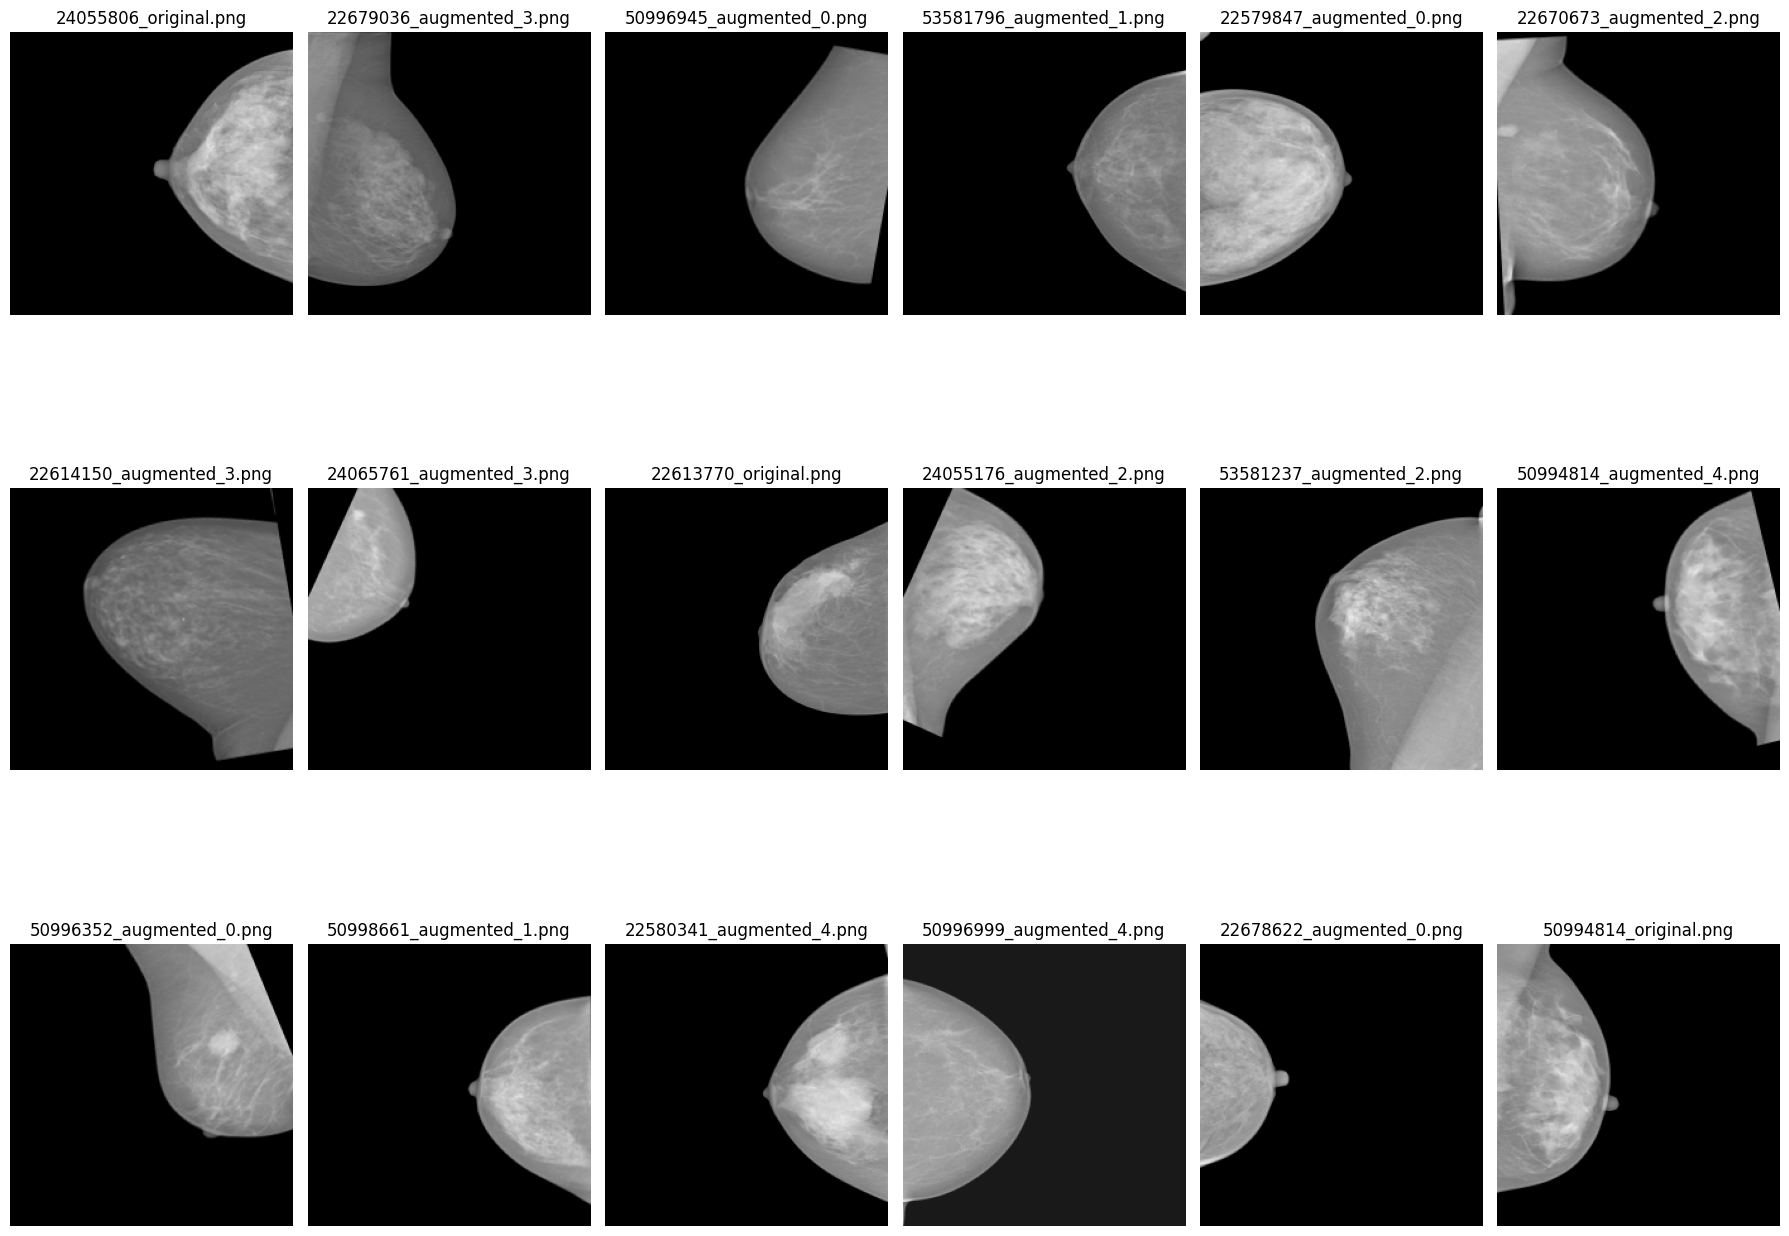

In [236]:
# see random sample of augmented images
import random
import matplotlib.pyplot as plt

num_preview_images = 18
images_per_row = 6
sample_images = random.sample(list(aug_df['image_path']), num_preview_images)
num_rows = (num_preview_images + images_per_row - 1) // images_per_row
plt.figure(figsize=(3 * images_per_row, 5 * num_rows))
for idx, img_path in enumerate(sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    row = idx // images_per_row
    col = idx % images_per_row
    plt.subplot(num_rows, images_per_row, idx + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')
plt.tight_layout()
plt.show()